In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import pylab
import seaborn as sns 
import os

In [3]:
import pydicom

## Load metadata file

In [4]:
!ls /kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection

stage_2_sample_submission.csv  stage_2_test  stage_2_train  stage_2_train.csv


In [5]:
ROOT = "/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection"

In [6]:
metadata_path =  ROOT + "/stage_2_train.csv"
train_img_dir = ROOT + "/stage_2_train"
test_img_dir = ROOT + "/stage_2_test"

In [7]:
train = pd.read_csv(metadata_path)

In [8]:
train.shape

(4516842, 2)

In [9]:
train.columns 

Index(['ID', 'Label'], dtype='object')

check the missing value 

In [10]:
train_copy = train.copy() 

In [11]:
train_copy['Label'].isnull().sum()

np.int64(0)

No missing value

## Check the image directory

In [12]:
def get_first_n_files(directory, n=10):
    file_list = []
    with os.scandir(directory) as entries:
        for entry in entries:
            if entry.is_file():
                file_list.append(entry.name)
                if len(file_list) >= n:
                    break
    return file_list

In [13]:
train_imgs_samples = get_first_n_files(train_img_dir, 50)
test_imgs_samples = get_first_n_files(test_img_dir, 50)

In [14]:
print('10 train imgs: ', train_imgs_samples[:10])

10 train imgs:  ['ID_27a354d42.dcm', 'ID_9ef779a18.dcm', 'ID_5bed38bf6.dcm', 'ID_286599272.dcm', 'ID_bba76cea8.dcm', 'ID_a917377cd.dcm', 'ID_7723b03a6.dcm', 'ID_dbb1cc814.dcm', 'ID_4b08fe185.dcm', 'ID_8192d735e.dcm']


In [15]:
print("10 test imgs: ", test_imgs_samples[:10])

10 test imgs:  ['ID_8bab87943.dcm', 'ID_e9c820cbc.dcm', 'ID_ae9a6e3ca.dcm', 'ID_5be923dc9.dcm', 'ID_a90458b64.dcm', 'ID_b18ea4888.dcm', 'ID_58cf4152e.dcm', 'ID_bd613f938.dcm', 'ID_e9d5b233e.dcm', 'ID_7a78723f3.dcm']


## Check Images 

### Overview of DICOM files and medical images
medical images are stored in a special format know as DICOM files `(*.dcm)`. They contain a combination of header metadata as well as underlying raw image arrays for pixel data. In python, one popular library to access and manipulate `DICOM` files iss the the **pydicom** module. TO use the **pydicom** library, first find the DICOM files for a given patientID by simply looking for the matching file in *Image folder* and the use pydicom.read_file() method to load the data

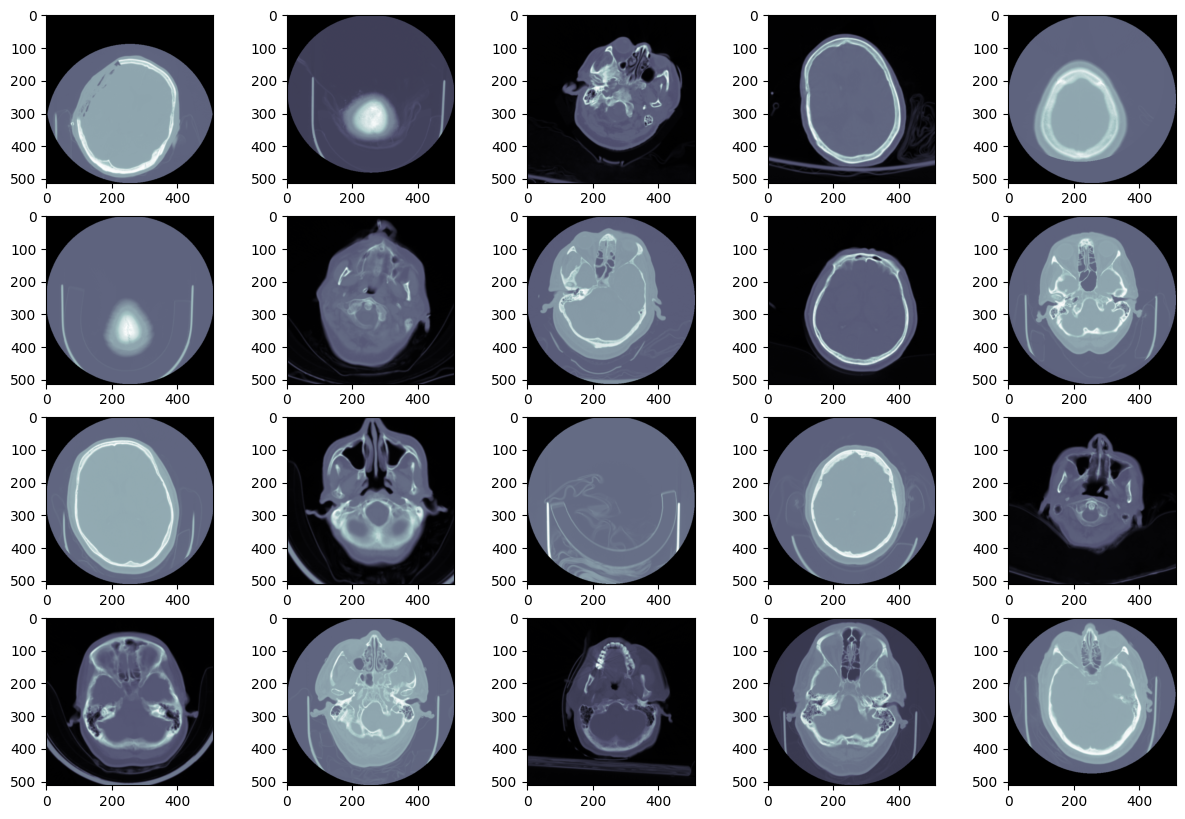

In [16]:
fig = plt.figure(figsize=(15, 10))
columns = 5
rows = 4

for i in range(1, columns*rows + 1): 
    ds = pydicom.dcmread(train_img_dir + '/' + train_imgs_samples[i]) 

    fig.add_subplot(rows, columns, i) 
    plt.imshow(ds.pixel_array, cmap=plt.cm.bone) 
    fig.add_subplot

In [17]:
print(ds)

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 188
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.840.4267.32.281664957337851357059828970761455249908
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.40.0.13.1.1.1
(0002,0013) Implementation Version Name         SH: 'dcm4che-1.4.35'
-------------------------------------------------
(0008,0018) SOP Instance UID                    UI: ID_d0bc20632
(0008,0060) Modality                            CS: 'CT'
(0010,0020) Patient ID                          LO: 'ID_6a954d3e'
(0020,000D) Study Instance UID                  UI: ID_c9ffa5cdfc
(0020,000E) Series Instance UID                 UI: ID_dd1f514c4b
(0020,0010) Study ID                            SH: ''
(0020,0032)

/usr/local/lib/python3.12/dist-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: 'ID_d0bc20632'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
/usr/local/lib/python3.12/dist-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: 'ID_c9ffa5cdfc'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
/usr/local/lib/python3.12/dist-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: 'ID_dd1f514c4b'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)


In [18]:
im = ds.pixel_array 
print(type(im))
print(im.dtype)
print(im.shape)

<class 'numpy.ndarray'>
int16
(512, 512)


## Visulization data

check the label distribution 

In [19]:
label_counts = train['Label'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']

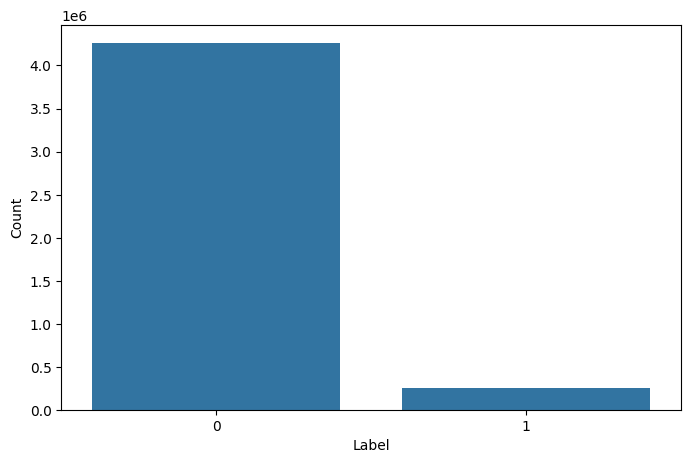

In [20]:
plt.figure(figsize=(8, 5))
sns.barplot(data=label_counts, x='Label', y='Count')
plt.show()

Take a look at fir DICOM image. Use pylab.imshow() mtd. 

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

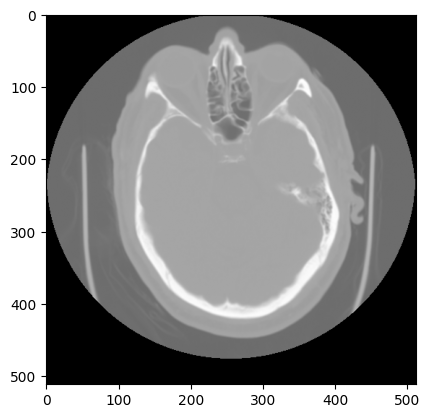

In [21]:
pylab.imshow(im, cmap=pylab.cm.gist_gray) 
pylab.axis('on')

## Define new Dataframe 

In [22]:
id_parts = train['ID'].str.split('_', n=3)
train['PatientID'] = id_parts.str[1]
train['Sub_type'] = id_parts.str[2]

**Interpretation note.** The column named `PatientID` below is extracted from the competition label key `ID_<image-id>_<subtype>`. It is an image ID, not the DICOM `PatientID`; do not use it for patient counts or patient-level split checks. The notebook reports positive image-label rows, not positive patients.

In [23]:
train.head(5)

,ID,Label,PatientID,Sub_type
0,ID_12cadc6af_epidural,0,12cadc6af,epidural
1,ID_12cadc6af_intraparenchymal,0,12cadc6af,intraparenchymal
2,ID_12cadc6af_intraventricular,0,12cadc6af,intraventricular
3,ID_12cadc6af_subarachnoid,0,12cadc6af,subarachnoid
4,ID_12cadc6af_subdural,0,12cadc6af,subdural


In [26]:
subTypeSum = train.groupby('Sub_type')['Label'].sum().reset_index()

subTypeSum

,Sub_type,Label
0,any,107933
1,epidural,3145
2,intraparenchymal,36118
3,intraventricular,26205
4,subarachnoid,35675
5,subdural,47166


/tmp/ipykernel_58/607505415.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=subTypeSum.index, x=subTypeSum.Label, palette="deep")


<Axes: xlabel='Label', ylabel='None'>

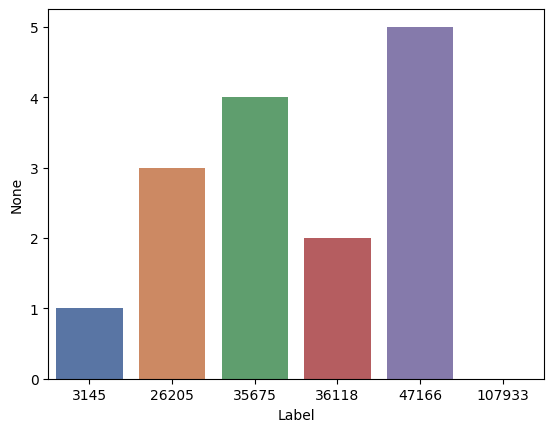

In [28]:
sns.barplot(y=subTypeSum.index, x=subTypeSum.Label, palette="deep")

Text(0.5, 1.0, 'Total Images by Subtype')

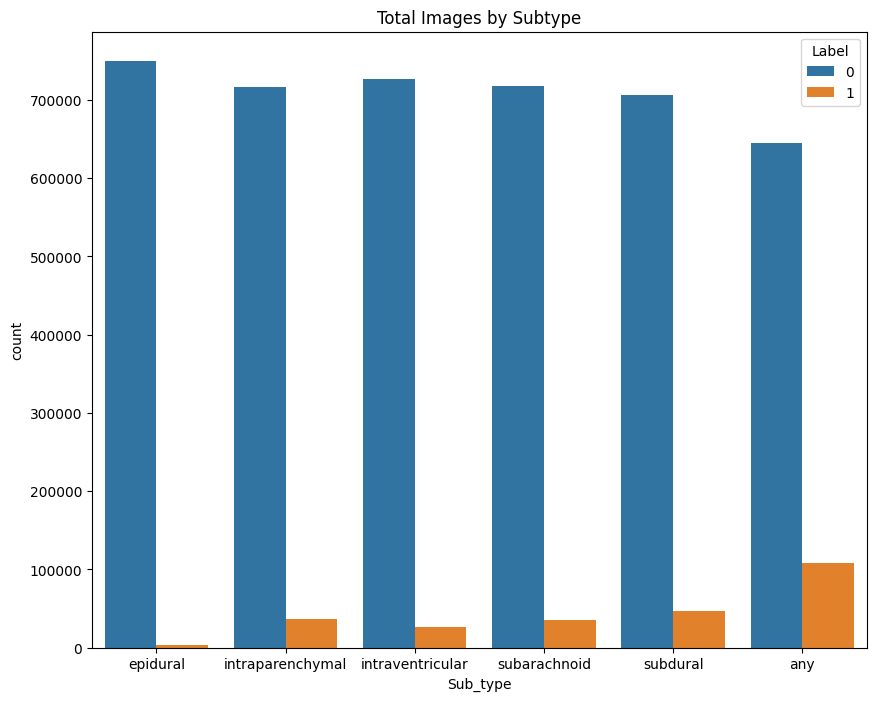

In [29]:
fig=plt.figure(figsize=(10, 8))

sns.countplot(x="Sub_type", hue="Label", data=train)

plt.title("Total Images by Subtype")

## Visualization of hemorrhage epidural 

Reference of Correcting windows : https://www.kaggle.com/omission/eda-view-dicom-images-with-correct-windowing @Richard_McKinley

In [38]:
def window_image(img, window_center,window_width, intercept, slope):
    # add cast to float 32 - a little fix for this function 
    img = img.astype(np.float32)
    
    img = (img*slope +intercept)
    img_min = window_center - window_width//2
    img_max = window_center + window_width//2
    img[img<img_min] = img_min
    img[img>img_max] = img_max
    return img 

In [31]:
def get_first_of_dicom_field_as_int(x):
    #get x[0] as in int is x is a 'pydicom.multival.MultiValue', otherwise get int(x)
    if type(x) == pydicom.multival.MultiValue:
        return int(x[0])
    else:
        return int(x)

def get_windowing(data):
    dicom_fields = [data[('0028','1050')].value, #window center
                    data[('0028','1051')].value, #window width
                    data[('0028','1052')].value, #intercept
                    data[('0028','1053')].value] #slope
    return [get_first_of_dicom_field_as_int(x) for x in dicom_fields]

In [36]:
def view_images(images, title = '', aug = None):
    width = 5
    height = 2
    fig, axs = plt.subplots(height, width, figsize=(15,5))
    
    for im in range(0, height * width):
        ''''
        image = pydicom.read_file(os.path.join(train_images_dir,'ID_'+images[im]+ '.dcm')).pixel_array
        i = im // width
        j = im % width
        axs[i,j].imshow(image, cmap=plt.cm.bone) 
        axs[i,j].axis('off')'''''
        
        data = pydicom.dcmread(os.path.join(train_img_dir,'ID_'+images[im]+ '.dcm'))
        image = data.pixel_array
        window_center , window_width, intercept, slope = get_windowing(data)
        image_windowed = window_image(image, window_center, window_width, intercept, slope)


        i = im // width
        j = im % width
        axs[i,j].imshow(image_windowed, cmap=plt.cm.bone) 
        axs[i,j].axis('off')
        
        
    plt.suptitle(title)
    plt.show()

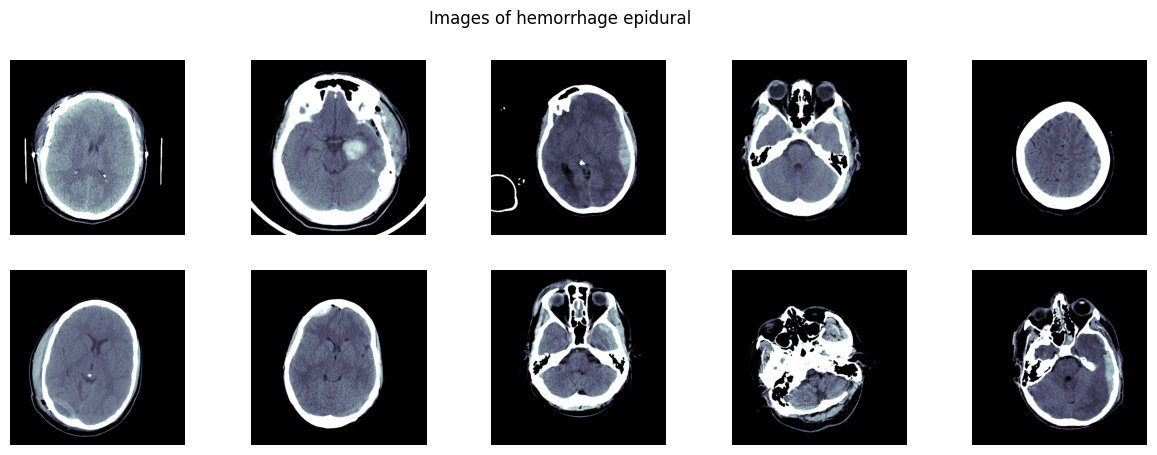

In [39]:
view_images(train[(train['Sub_type'] == 'epidural') & (train['Label'] == 1)][:10].PatientID.values, title = 'Images of hemorrhage epidural')

## Visualization of hemorrhage intraparenchymal 

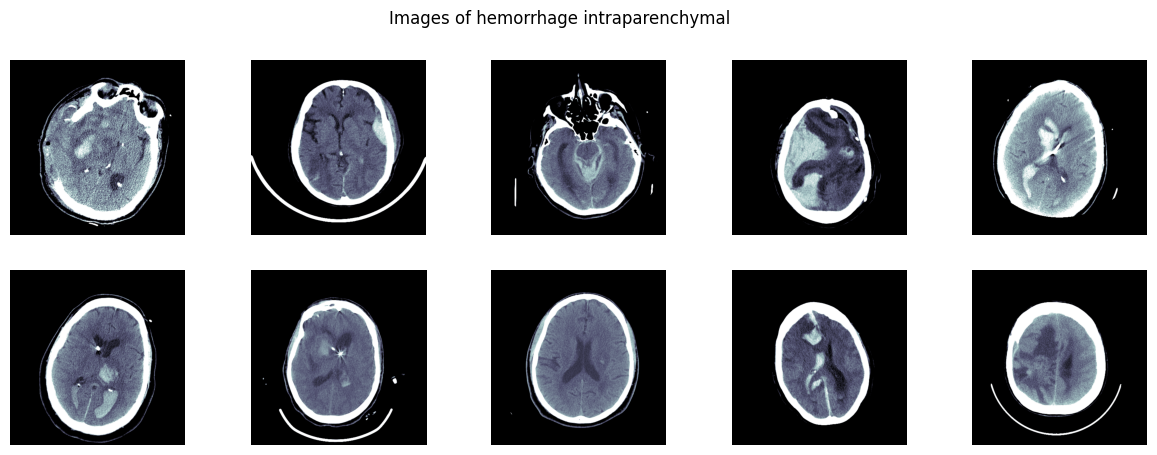

In [40]:
view_images(train[(train['Sub_type'] == 'intraparenchymal') & (train['Label'] == 1)][:20].PatientID.values, title = 'Images of hemorrhage intraparenchymal')

## Visulization of hemorrhage intraventricular 


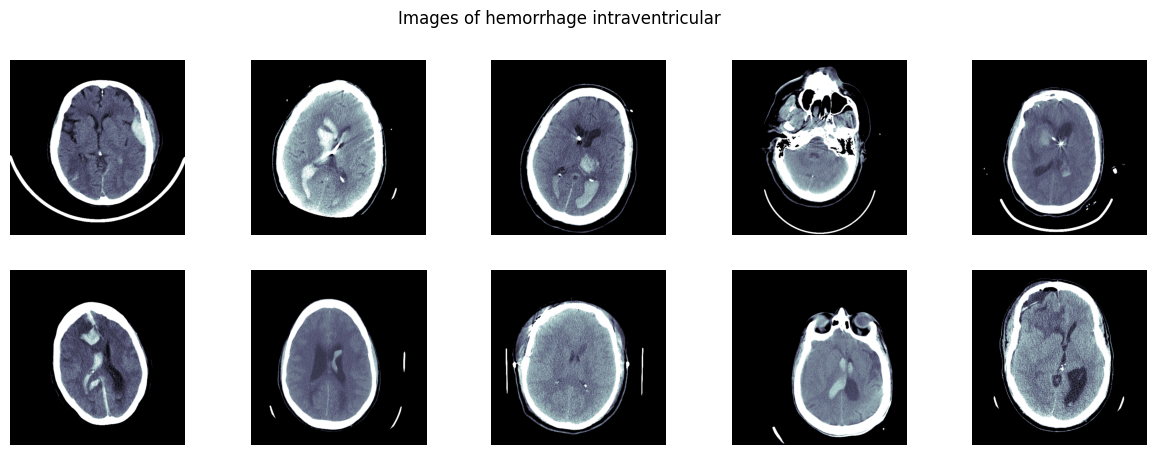

In [42]:
view_images(train[(train['Sub_type'] == 'intraventricular') & (train['Label'] == 1)][:20].PatientID.values, title = 'Images of hemorrhage intraventricular')

## Visualization of hemorrhage subarachnoid 

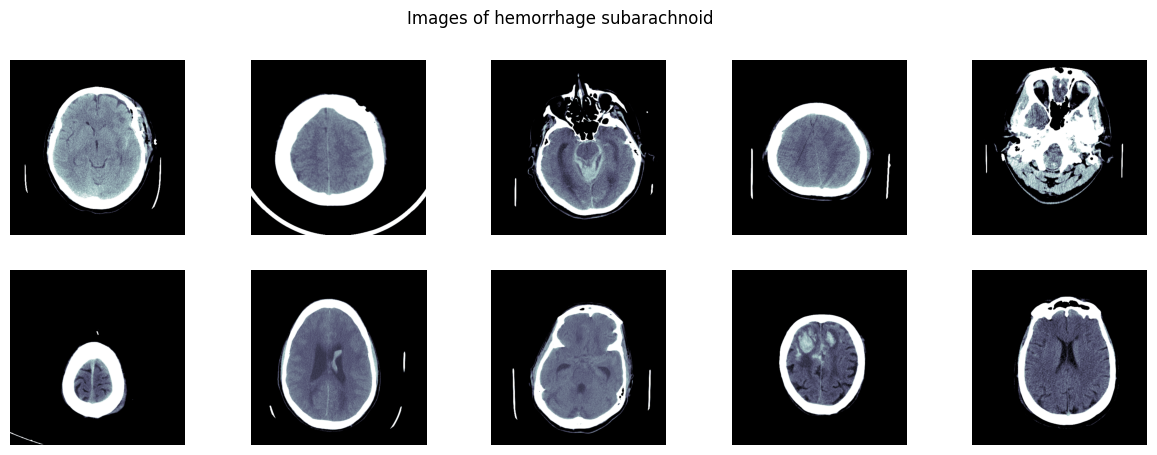

In [41]:
view_images(train[(train['Sub_type'] == 'subarachnoid') & (train['Label'] == 1)][:20].PatientID.values, title = 'Images of hemorrhage subarachnoid')

## Visualization of hemorrhage subdural 

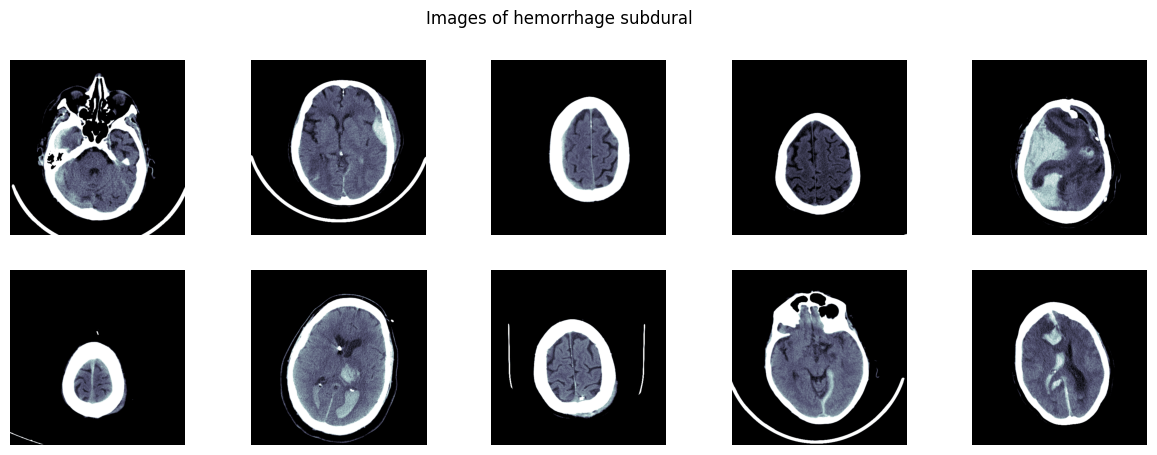

In [43]:
view_images(train[(train['Sub_type'] == 'subdural') & (train['Label'] == 1)][:20].PatientID.values, title = 'Images of hemorrhage subdural')